In [6]:
# Roll No: 24BAD047

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier

In [7]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\4_sem\ML\EX_NO_6\heart_stacking.csv")

In [8]:
df.columns = df.columns.str.strip()

In [9]:
target_col = "HeartDisease"

In [10]:
X = df.drop(target_col, axis=1)
y = df[target_col]

print("Class Distribution:\n", y.value_counts())

Class Distribution:
 HeartDisease
1    83
0    37
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

stack = StackingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('dt', dt)],
    final_estimator=LogisticRegression()
)

In [13]:
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)
stack.fit(X_train, y_train)

,estimators,"[('lr', ...), ('svm', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [14]:
acc_lr = accuracy_score(y_test, lr.predict(X_test))
acc_svm = accuracy_score(y_test, svm.predict(X_test))
acc_dt = accuracy_score(y_test, dt.predict(X_test))
acc_stack = accuracy_score(y_test, stack.predict(X_test))

In [15]:
print("Logistic Regression:", acc_lr)
print("SVM:", acc_svm)
print("Decision Tree:", acc_dt)
print("Stacking:", acc_stack)


Logistic Regression: 0.7916666666666666
SVM: 0.875
Decision Tree: 1.0
Stacking: 1.0


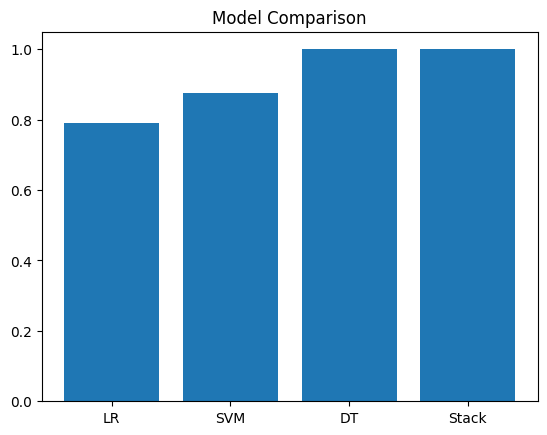

In [16]:
plt.figure()
plt.bar(["LR","SVM","DT","Stack"], [acc_lr, acc_svm, acc_dt, acc_stack])
plt.title("Model Comparison")
plt.show()